# Data & Visual Analysis: FEMA Impact in Appalachia

This notebook contains the data cleaning, spatial analysis, and visual pipeline supporting the white paper:

> **"Defunding, Dismantling, and Disarray: Tracking the Changes to FEMA and its Impact in the Appalachian Region"**  
> *Published with Reimagine Appalachia*  
> 📄 [View Full Report (PDF)](https://reimagineappalachia.org/wp-content/uploads/2026/05/Defunding-Dismantling-and-Disarray.pdf)

---

### **Overview & Objectives**
* Ingest and clean OpenFEMA disaster grant data and regional flood risk indicators.
* Analyze historical trends in disaster assistance allocations across Appalachian counties.
* Generate publication-ready figures and geospatial maps featured in the final report.

---

In [80]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker
import matplotlib.patheffects as pe
import textwrap



In [81]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Setting Style to Match Brand Identity

In [82]:
# setting the visual styles
sns.set_theme(context='notebook',
              style='whitegrid',
              font='sans-serif',
              font_scale=1,
              color_codes=True)

# color mappng
state_colors = {
    'PA': '#77c043',  # green
    'OH': '#80d0d8',          # light blue
    'KY': '#ed9a22',      # Purple
    'WV': '#006e82' # dark blue
}

import matplotlib.pyplot as plt

# Set these before you start plotting
plt.rcParams.update({
    'font.size': 12,          # Default text size
    'axes.titlesize': 16,     # Title size
    'axes.labelsize': 14,     # X and Y axis labels (if you had them)
    'xtick.labelsize': 12,    # X-axis tick numbers
    'ytick.labelsize': 12,    # Y-axis tick numbers
    'legend.fontsize': 11,    # Legend text
    'font.family': 'sans-serif' # Optional: cleaner look
})
ri_palette = ["#77c043", "#80d0d8", "#1896ae", "#006e82"]

# formatter for the numbers
def human_format(num, pos=None):
    magnitude = 0
    if abs(num) < 1: return "0"
    while abs(num) >= 1000:
        magnitude += 1
        num /= 1000.0
    return '%.1f%s' % (num, ['', 'K', 'M', 'B', 'T'][magnitude])

# formatting to billions for readability
def billions_formatter(x, pos):
    return f'{x * 1e-9:.1f}B'

In [83]:
# loading data
df = pd.read_csv("/content/drive/Shareddrives/ReImagine Appalachia Shared Drive (2026)/Research/Flatline Report Research/FEMA Changes 2025 Research/FEMA Data/final Analysis (using dashboard data for final report)/fema-footprint/fema_by_state_geography.csv")

In [84]:
my_path = ('/content/drive/Shareddrives/ReImagine Appalachia Shared Drive (2026)/Research/Flatline Report Research/FEMA Changes 2025 Research/FEMA Data/final Analysis (using dashboard data for final report)/fema-footprint/')

In [85]:
# Check what the extra rows are
print(df[df["state_code"].isna() | ~df["state_code"].isin([
    "AL","AK","AZ","AR","CA","CO","CT","DE","FL","GA",
    "HI","ID","IL","IN","IA","KS","KY","LA","ME","MD",
    "MA","MI","MN","MS","MO","MT","NE","NV","NH","NJ",
    "NM","NY","NC","ND","OH","OK","OR","PA","RI","SC",
    "SD","TN","TX","UT","VT","VA","WA","WV","WI","WY"
])])

# Filter to 50 states only
states_50 = [
    "AL","AK","AZ","AR","CA","CO","CT","DE","FL","GA",
    "HI","ID","IL","IN","IA","KS","KY","LA","ME","MD",
    "MA","MI","MN","MS","MO","MT","NE","NV","NH","NJ",
    "NM","NY","NC","ND","OH","OK","OR","PA","RI","SC",
    "SD","TN","TX","UT","VT","VA","WA","WV","WI","WY"
]

df_state = df[df["state_code"].isin(states_50)].reset_index(drop=True)

   state_code                     state   obligations  per_capita_obligations  \
8          PR               Puerto Rico  3.409593e+09                 1037.65   
10         DC      District Of Columbia  3.176359e+09                 4606.46   
52         VI       U.S. Virgin Islands  1.707632e+08                 1959.51   
53         MP  Northern Mariana Islands  1.520109e+08                 3211.79   
54         GU                      Guam  1.343896e+08                  873.59   
55         AS            American Samoa  4.690123e+07                  943.50   
56        NaN                       NaN  2.000000e+05                     NaN   

   obligations_fmt per_capita_fmt  
8   $3,409,593,312         $1,037  
10  $3,176,358,964         $4,606  
52    $170,763,238         $1,959  
53    $152,010,891         $3,211  
54    $134,389,637           $873  
55     $46,901,230           $943  
56        $200,000            NaN  


In [86]:
df_four_state = df_state[df_state["state_code"].isin(["PA", "OH", "KY", "WV"])].copy()

# Analysis of Grant Obligations


In [87]:
print(f"{df_four_state["obligations"].sum():,}")

5,908,481,948.02


## Obligations by State

In [88]:
import plotly.express as px
import plotly.io as pio

# Forces Plotly to write inline JavaScript directly into notebook cells
pio.renderers.default = "notebook_connected"

# 1. Logic using 'obligations' and 'df_four_state'
max_val = df_four_state['obligations'].max()
df_four_state['text_color'] = df_four_state['obligations'].apply(
    lambda x: 'white' if x == max_val else 'black'
)

df_four_state['label_text'] = df_four_state.apply(
    lambda row: f"{row['state_code']}<br>${(row['obligations']/1_000_000_000):.1f}B",
    axis=1
)

# 2. Create map with 'obligations' column
fig = px.choropleth(
    df_four_state,
    locations='state_code',
    locationmode="USA-states",
    color='obligations', # Standardized to 'obligations'
    scope="usa",
    color_continuous_scale="Teal"
)

# 3. Add labels referencing 'df_four_state'
fig.add_scattergeo(
    locations=df_four_state['state_code'],
    locationmode="USA-states",
    text=df_four_state['label_text'], # Fixed variable name
    mode='text',
    textposition="middle center",
    textfont=dict(
        size=20,
        color=df_four_state['text_color'] # Fixed variable name
    ),
)

fig.update_layout(
    title={
        'text': 'Total FEMA Grant Obligations (2020 - 2025)',
        'y': .89,
        'x': 0.5,
        'xanchor': 'center',
        'yanchor': 'top',
        'font': {'size': 24}
    },
    width=800,
    height=600,
    margin={"r":0, "t":50, "l":0, "b":0},
    coloraxis_showscale=False,
    geo_bgcolor='white',
    paper_bgcolor='white'
)

fig.update_geos(
    showland=True,
    landcolor="#eeeeee",
    showsubunits=True,
    subunitcolor="white",
    fitbounds="locations", # Zooms to your 4 states
    visible=False
)

fig.show()

## Obligations over time

In [89]:
df_time = pd.read_csv("/content/drive/Shareddrives/ReImagine Appalachia Shared Drive (2026)/Research/Flatline Report Research/FEMA Changes 2025 Research/FEMA Data/final Analysis (using dashboard data for final report)/fema-footprint/results_over_time.csv")

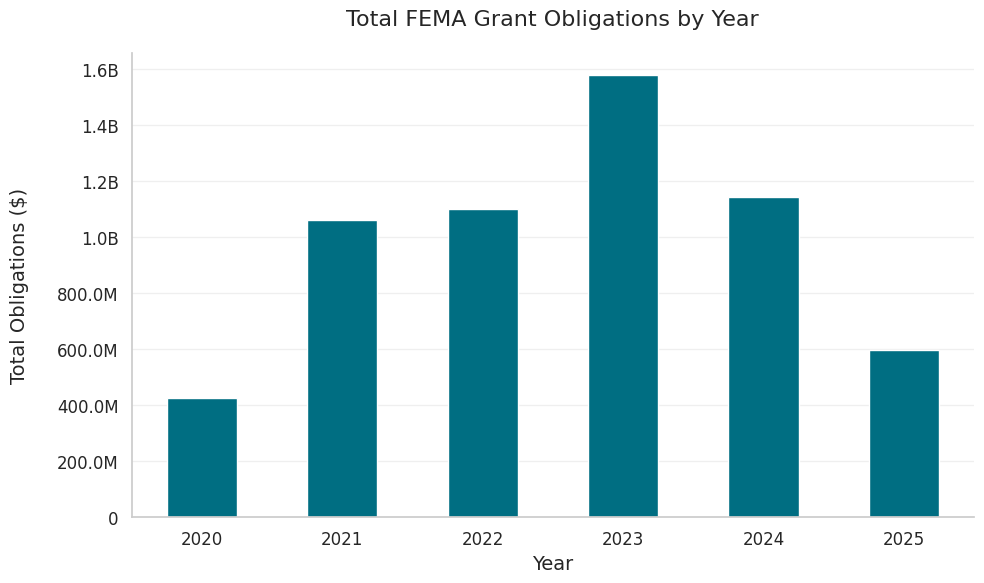

In [90]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# 1. Convert to datetime
df_time['date_column'] = pd.to_datetime(df_time['month'], format='%b %Y')

# 2. Group by Year and Sum
df_yearly = df_time.groupby(df_time['date_column'].dt.year)['total_obligations'].sum()

# 3. Plotting
ax = df_yearly.plot(kind='bar', color='#006e82', figsize=(10, 6), rot=0)

# 4. Apply the formatter to the Y-axis
formatter = FuncFormatter(human_format)
ax.yaxis.set_major_formatter(formatter)

# --- FORMATTING LOGIC ---

# Turn off vertical grid lines, keep horizontal ones
ax.grid(axis='y', alpha=0.3) # Lowered alpha for a cleaner look
ax.grid(axis='x', visible=False)

# REMOVE TOP AND RIGHT SPINES
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Optional: Make the remaining spines a lighter grey to match the aesthetic
ax.spines['left'].set_color('#cccccc')
ax.spines['bottom'].set_color('#cccccc')

# Adjust y-label distance
plt.ylabel('Total Obligations ($)', fontsize=14, labelpad=20)

# -----------------------------

plt.title('Total FEMA Grant Obligations by Year', fontsize=16, pad=20)
plt.xlabel('Year', fontsize=14)

plt.tight_layout()

# Save and show
plt.savefig(my_path + 'total_obligations_by_year.png', dpi=300)
plt.show()

## Adjusting Obligations Per Capita

In [91]:
df_four_state

,state_code,state,obligations,per_capita_obligations,obligations_fmt,per_capita_fmt,text_color,label_text
13,PA,Pennsylvania,2.715542e+09,208.84,"$2,715,541,959",$208,white,PA<br>$2.7B
17,KY,Kentucky,1.500261e+09,332.96,"$1,500,260,975",$332,black,KY<br>$1.5B
21,OH,Ohio,1.234445e+09,104.62,"$1,234,444,590",$104,black,OH<br>$1.2B
43,WV,West Virginia,4.582344e+08,255.47,"$458,234,424",$255,black,WV<br>$0.5B


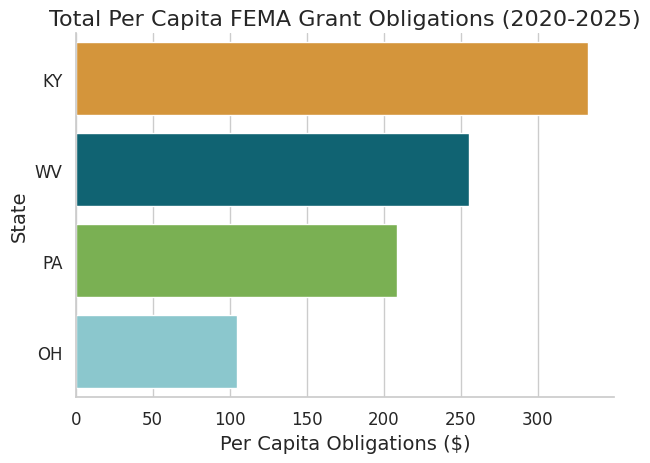

In [92]:
per_cap = df_four_state.sort_values(by="per_capita_obligations", ascending = False)
ax = sns.barplot(
    data=per_cap,
    x='per_capita_obligations',
    y='state_code',
    hue='state_code',
    palette=state_colors,
    estimator='sum', # Ensures the bar height is the total, not the average
    errorbar=None,   # Removes the error bars
    legend=False
)

plt.title('Total Per Capita FEMA Grant Obligations (2020-2025)')
plt.xlabel('Per Capita Obligations ($)')
plt.ylabel("State")

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

formatter = FuncFormatter(human_format)

# Use the correct function call (no quotes, underscore between words)
plt.tight_layout()

# Add bbox_inches='tight' to the savefig call
plt.savefig(my_path + 'per_capita.png', dpi=300, bbox_inches='tight')




## Downloading Notebook

In [94]:
# 1. Save current notebook state to Colab workspace
from google.colab import files, _message
import json

try:
    # Fetch notebook JSON
    notebook_json = _message.blocking_request('get_ipynb', timeout_sec=300)['ipynb']

    with open('fema_footprint.ipynb', 'w', encoding='utf-8') as f:
        json.dump(notebook_json, f)

    print("Saved notebook to fema_footprint.ipynb")

    # 2. Convert to HTML with fully embedded Plotly JS and resources
    !jupyter nbconvert --to html fema_footprint.ipynb --embed-resources --HTMLExporter.theme=light

    # 3. Download HTML file
    files.download('fema_footprint.html')

except Exception as e:
    print("Error:", e)

Saved notebook to fema_footprint.ipynb
usage: jupyter-nbconvert [-h] [--debug] [--show-config] [--show-config-json]
                         [--generate-config] [-y] [--execute] [--allow-errors]
                         [--stdin] [--stdout] [--inplace] [--clear-output]
                         [--coalesce-streams] [--no-prompt] [--no-input]
                         [--allow-chromium-download]
                         [--disable-chromium-sandbox] [--show-input]
                         [--embed-images] [--sanitize-html]
                         [--log-level NbConvertApp.log_level]
                         [--config NbConvertApp.config_file]
                         [--to NbConvertApp.export_format]
                         [--template TemplateExporter.template_name]
                         [--template-file TemplateExporter.template_file]
                         [--theme HTMLExporter.theme]
                         [--sanitize_html HTMLExporter.sanitize_html]
                         [

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>